# Student Performance Indicator

## Lifecycle
- Understanding the Problem Statement 
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1. Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2. Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [3]:
df = pd.read_csv('./data/stud.csv')

#### Top 5 records of the dataset

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [9]:
print(f"Shape of the dataset: {df.shape[0]} rows and {df.shape[1]} columns")

Shape of the dataset: 1000 rows and 8 columns


### 2.2 Dataset information
- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B, C, D, E) - **Question- what do these groups mean?**
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### 3.1 Checking missing values

In [ ]:
# checking if there are any missing values in the dataset
missing_values = df.isnull().sum() 
missing_values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
Total_Score                    0
Average_Score                  0
dtype: int64

Observation- there are no missing values in the dataset

#### Check Duplicates

In [14]:
print(f"Number of duplicate rows in the dataset: {df.duplicated().sum()}")

Number of duplicate rows in the dataset: 0


Observation- There are No duplicate rows in the dataset

#### Check datatypes

df.info()

Observation- 4 `object` types, and 3 `integer` types

#### Checking unique values of each column

In [20]:
# axis=0 / 'index':   look DOWN the rows → one count per column
df.nunique(axis=0)

# axis=1 / 'columns': look ACROSS the columns → one count per row
df.nunique(axis=1)

0      7
1      8
2      8
3      8
4      8
      ..
995    8
996    7
997    8
998    8
999    7
Length: 1000, dtype: int64

### 3.5 Check statistics of dataset

In [53]:
df.describe().round(2)

,math_score,reading_score,writing_score,Total_Score,Average_Score
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05,203.31,67.77
std,15.16,14.60,15.20,42.77,14.26
min,0.00,17.00,10.00,27.00,9.00
25%,57.00,59.00,57.75,175.00,58.33
50%,66.00,70.00,69.00,205.00,68.33
75%,77.00,79.00,79.00,233.00,77.67
max,100.00,100.00,100.00,300.00,100.00


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 3.6 Exploring Data

In [29]:
# Categorical Columns - object, string, category, etc.
print(f"Categorical Columns: {df.select_dtypes(include='object').columns.tolist()}")

# Numerical Columns - int64, float64, etc. or np.number or 'number'
print(f"Numerical Columns: {df.select_dtypes(include='number').columns.tolist()}")

Categorical Columns: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Numerical Columns: ['math_score', 'reading_score', 'writing_score']


### 3.7 Checking Unique values for each column

In [40]:
# Gender
print(f"Unique values in 'gender' column: {df['gender'].unique()}")

# Race/Ethnicity
print(f"Unique values in Race/Ethnicity column (sorted asc): {sorted(df['race_ethnicity'].unique())}")

# Parental Level of Education
print(f"Unique values in Parental Level of Education column (sorted asc): {sorted(df['parental_level_of_education'].unique())}")

# Lunch
print(f"Unique values in Lunch column (sorted asc): {sorted(df['lunch'].unique())}")

# Test Preparation Course
print(f"Unique values in Test Preparation Course column (sorted asc): {sorted(df['test_preparation_course'].unique())}")



Unique values in 'gender' column: ['female' 'male']
Unique values in Race/Ethnicity column (sorted asc): ['group A', 'group B', 'group C', 'group D', 'group E']
Unique values in Parental Level of Education column (sorted asc): ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school']
Unique values in Lunch column (sorted asc): ['free/reduced', 'standard']
Unique values in Test Preparation Course column (sorted asc): ['completed', 'none']


### 3.8 Adding columns for Total Score and Average Score

In [42]:
df['Total_Score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['Average_Score'] = (df['Total_Score'] / 3).round(2)
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_Score,Average_Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [45]:
reading_full = df[df['reading_score'] == 100]['Average_Score'].count()
writing_full = df[df['writing_score'] == 100]['Average_Score'].count()
math_full = df[df['math_score'] == 100]['Average_Score'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

print('-'*100)

reading_less_20 = df[df['reading_score'] <= 20]['Average_Score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['Average_Score'].count()
math_less_20 = df[df['math_score'] <= 20]['Average_Score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17
----------------------------------------------------------------------------------------------------
Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


### 4. Visualizeing Data

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

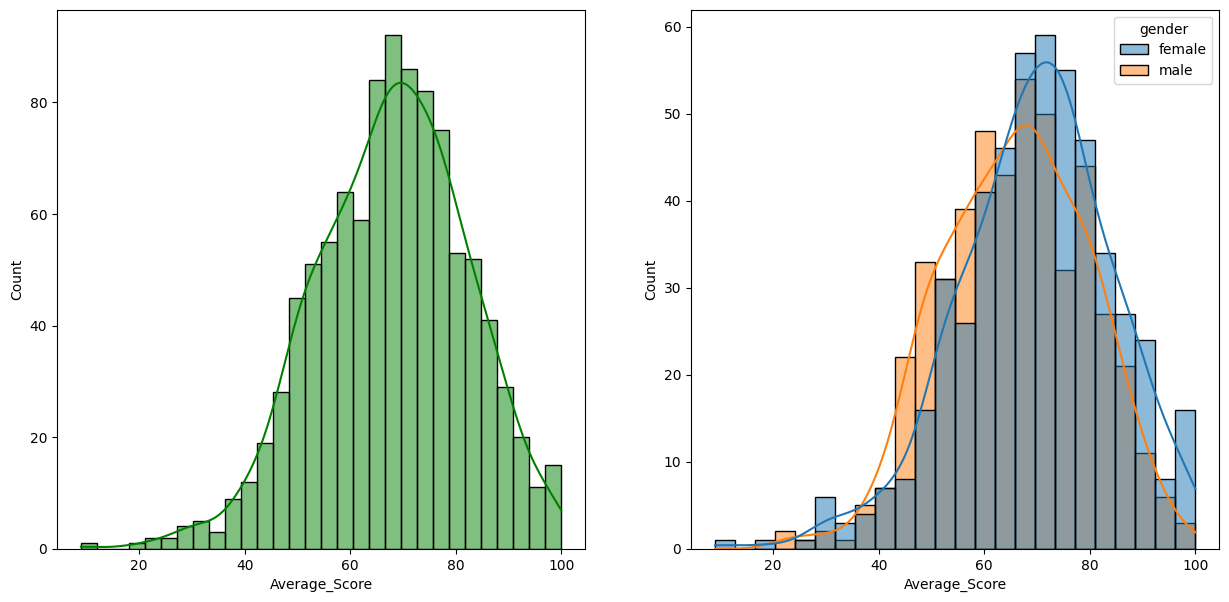

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Average_Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average_Score',kde=True,hue='gender')
plt.show()

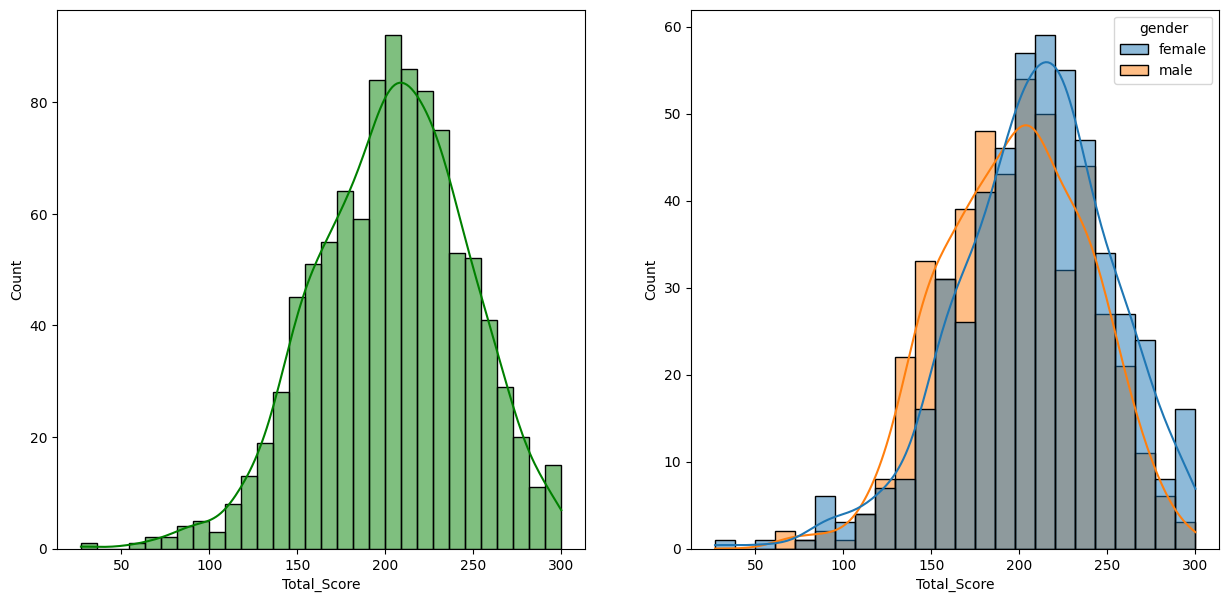

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='Total_Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total_Score',kde=True,hue='gender')
plt.show()

####  Observations:
- Female students tend to perform well then male students.

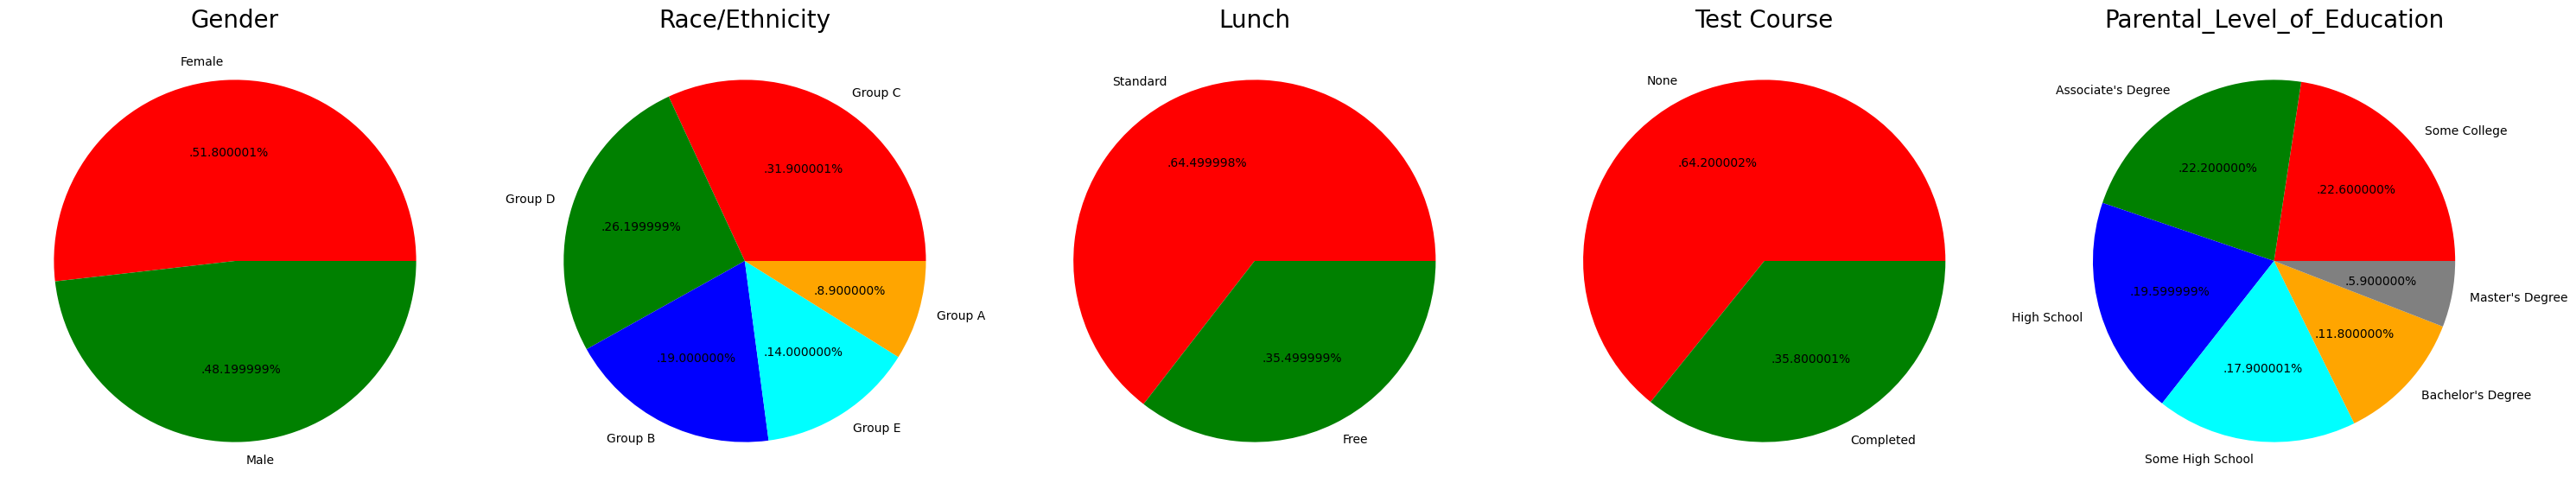

In [49]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental_Level_of_Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()